# Customer Behavior Analysis

## Alfido Tech Internship Project

This project analyzes customer purchasing behavior, customer segments,
retention patterns, and churn risk using the Customer Behavior Analysis dataset.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\ecommerce_customer_data_custom_ratios.csv\ecommerce_customer_data_custom_ratios.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 250000
Number of columns: 13


In [9]:
print("Columns in the dataset:\n")

for column in df.columns:
    print(column)

Columns in the dataset:

Customer ID
Purchase Date
Product Category
Product Price
Quantity
Total Purchase Amount
Payment Method
Customer Age
Returns
Customer Name
Age
Gender
Churn


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [11]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
df = df.drop_duplicates()

print("Duplicates removed.")
print("New dataset shape:", df.shape)

Duplicates removed.
New dataset shape: (250000, 13)


In [15]:
df["Purchase Date"] = pd.to_datetime(
    df["Purchase Date"],
    errors="coerce"
)

print(df["Purchase Date"].dtype)

datetime64[ns]


In [16]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [17]:
df["Returns"] = df["Returns"].fillna(0)

print("Missing values in Returns:", df["Returns"].isnull().sum())

Missing values in Returns: 0


In [18]:
numeric_columns = [
    "Product Price",
    "Quantity",
    "Total Purchase Amount",
    "Customer Age",
    "Returns"
]

df[numeric_columns].describe()

,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,254.659512,2.998896,2725.370732,43.940528,0.403076
std,141.568577,1.414694,1442.933565,15.350246,0.490517
min,10.000000,1.000000,100.000000,18.000000,0.000000
25%,132.000000,2.000000,1477.000000,31.000000,0.000000
50%,255.000000,3.000000,2724.000000,44.000000,0.000000
75%,377.000000,4.000000,3974.000000,57.000000,1.000000
max,500.000000,5.000000,5350.000000,70.000000,1.000000


In [19]:
df["Purchase Year"] = df["Purchase Date"].dt.year

df[["Purchase Date", "Purchase Year"]].head()

,Purchase Date,Purchase Year
0,2020-09-08 09:38:32,2020
1,2022-03-05 12:56:35,2022
2,2022-05-23 18:18:01,2022
3,2020-11-12 13:13:29,2020
4,2020-11-27 17:55:11,2020


In [20]:
df["Purchase Month"] = df["Purchase Date"].dt.month

df[["Purchase Date", "Purchase Month"]].head()

,Purchase Date,Purchase Month
0,2020-09-08 09:38:32,9
1,2022-03-05 12:56:35,3
2,2022-05-23 18:18:01,5
3,2020-11-12 13:13:29,11
4,2020-11-27 17:55:11,11


In [21]:
df["Month Name"] = df["Purchase Date"].dt.month_name()

df[["Purchase Date", "Month Name"]].head()

,Purchase Date,Month Name
0,2020-09-08 09:38:32,September
1,2022-03-05 12:56:35,March
2,2022-05-23 18:18:01,May
3,2020-11-12 13:13:29,November
4,2020-11-27 17:55:11,November


In [22]:
df["Day of Week"] = df["Purchase Date"].dt.day_name()

df[["Purchase Date", "Day of Week"]].head()

,Purchase Date,Day of Week
0,2020-09-08 09:38:32,Tuesday
1,2022-03-05 12:56:35,Saturday
2,2022-05-23 18:18:01,Monday
3,2020-11-12 13:13:29,Thursday
4,2020-11-27 17:55:11,Friday


In [23]:
df["Calculated Amount"] = (
    df["Product Price"] * df["Quantity"]
)

df[
    [
        "Product Price",
        "Quantity",
        "Calculated Amount",
        "Total Purchase Amount"
    ]
].head()

,Product Price,Quantity,Calculated Amount,Total Purchase Amount
0,12,3,36,740
1,468,4,1872,2739
2,288,2,576,3196
3,196,1,196,3509
4,449,1,449,3452


In [24]:
print("Total unique customers:",
      df["Customer ID"].nunique())

print("Total transactions:",
      len(df))

print("Total revenue:",
      df["Total Purchase Amount"].sum())

print("Average purchase amount:",
      df["Total Purchase Amount"].mean())

Total unique customers: 49673
Total transactions: 250000
Total revenue: 681342683
Average purchase amount: 2725.370732


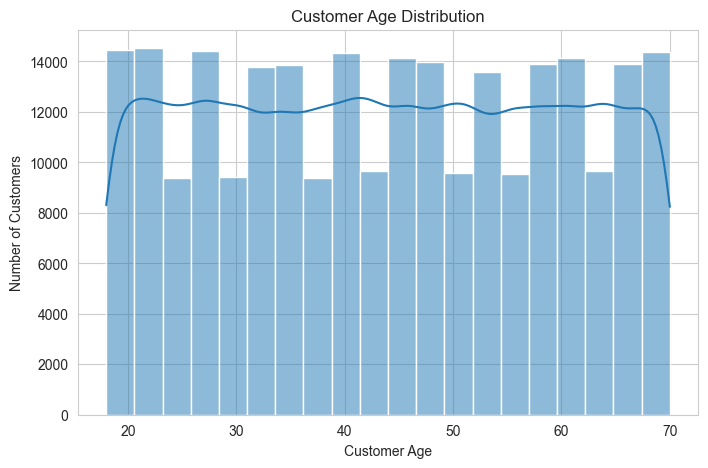

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Customer Age"],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.show()

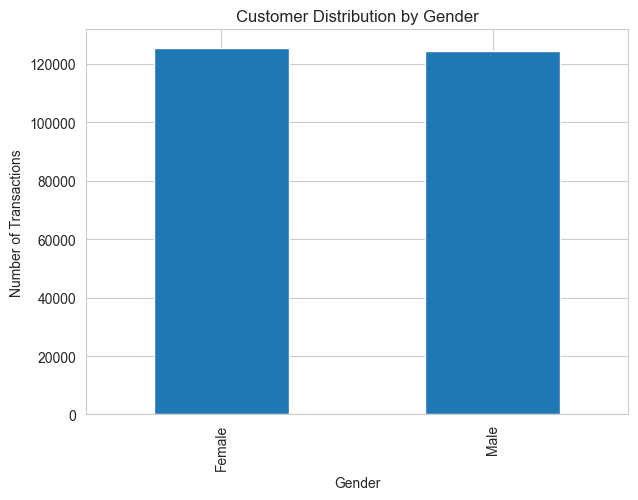

In [26]:
plt.figure(figsize=(7,5))

df["Gender"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")

plt.show()

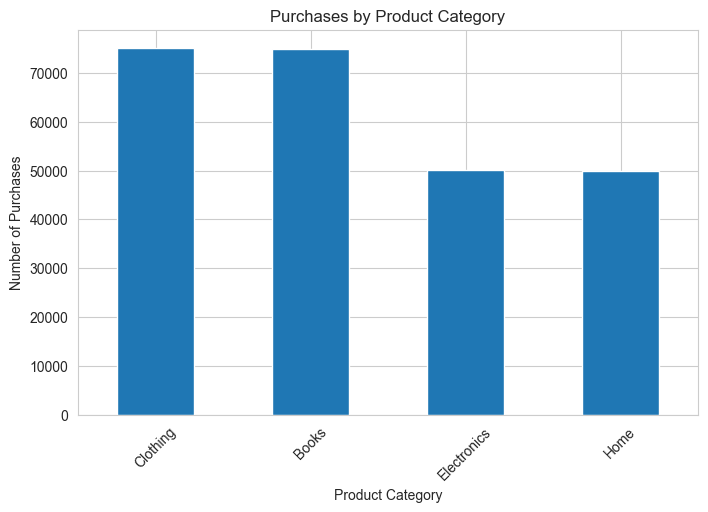

In [27]:
plt.figure(figsize=(8,5))

df["Product Category"].value_counts().plot(kind="bar")

plt.title("Purchases by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()

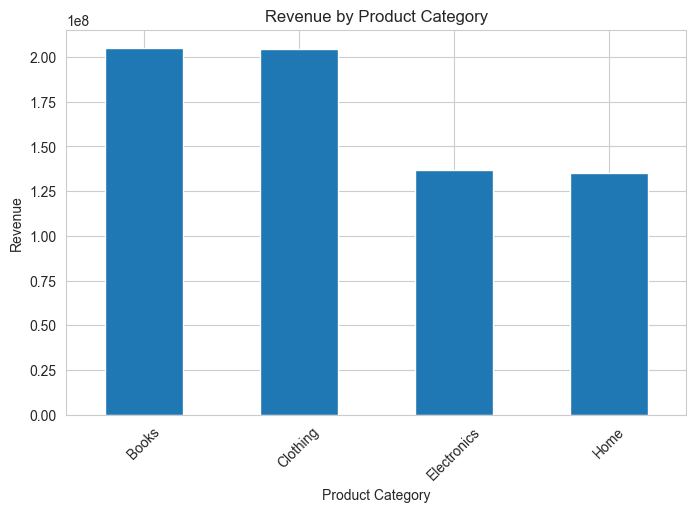

In [28]:
category_revenue = (
    df.groupby("Product Category")["Total Purchase Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

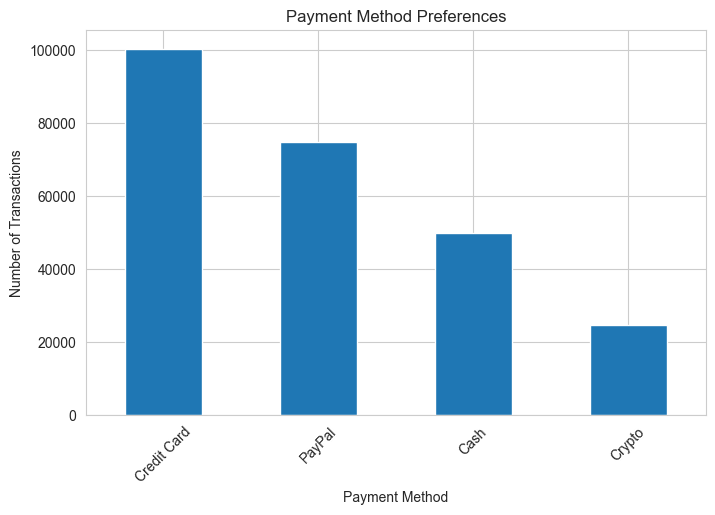

In [29]:
plt.figure(figsize=(8,5))

df["Payment Method"].value_counts().plot(kind="bar")

plt.title("Payment Method Preferences")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [30]:
monthly_revenue = (
    df.groupby(
        df["Purchase Date"].dt.to_period("M")
    )["Total Purchase Amount"]
    .sum()
)

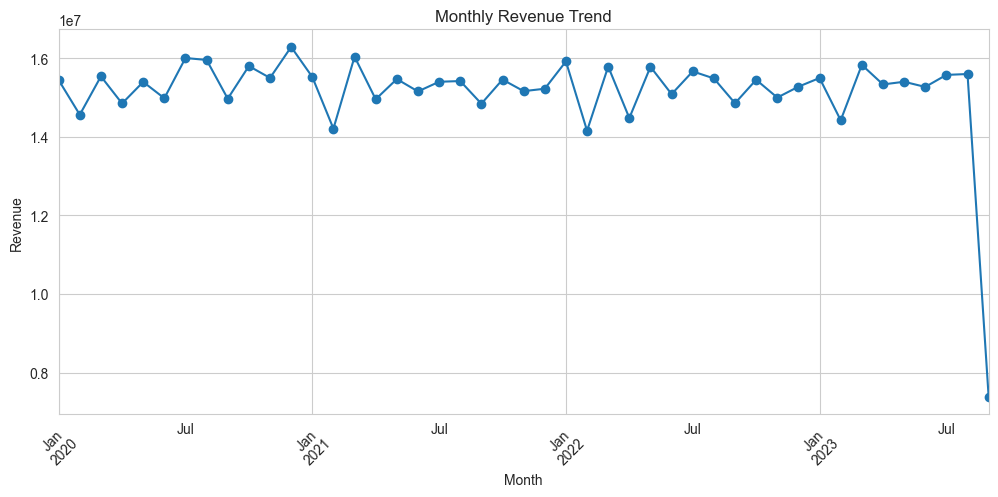

In [31]:
plt.figure(figsize=(12,5))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

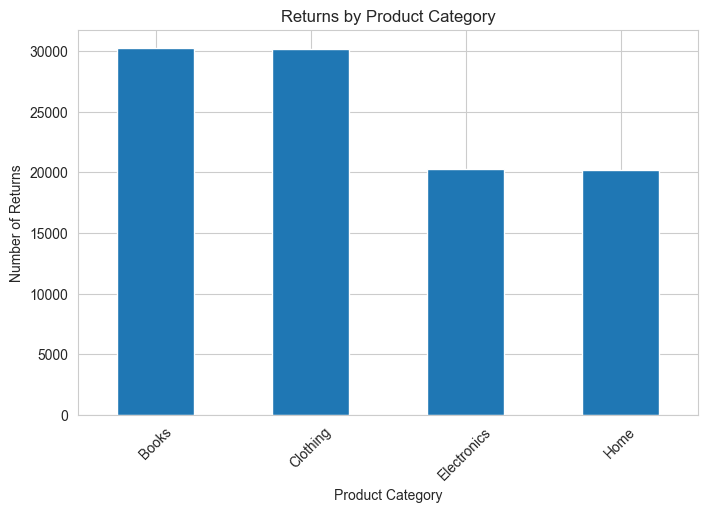

In [32]:
returns_by_category = (
    df.groupby("Product Category")["Returns"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

returns_by_category.plot(kind="bar")

plt.title("Returns by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Returns")

plt.xticks(rotation=45)

plt.show()

In [33]:
reference_date = (
    df["Purchase Date"].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby("Customer ID").agg(
    Recency=(
        "Purchase Date",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "Purchase Date",
        "count"
    ),
    Monetary=(
        "Total Purchase Amount",
        "sum"
    )
)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,58,1,3491
2,299,3,7988
3,89,8,22587
4,127,4,8715
5,171,8,12524


In [34]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1],
    duplicates="drop"
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5],
    duplicates="drop"
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1,2,3,4,5],
    duplicates="drop"
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
1,58,1,3491,5,1,1
2,299,3,7988,2,1,2
3,89,8,22587,4,5,5
4,127,4,8715,4,2,2
5,171,8,12524,3,5,3


In [35]:
def segment_customer(row):

    if (
        row["R_Score"] >= 4 and
        row["F_Score"] >= 4 and
        row["M_Score"] >= 4
    ):
        return "Champions"

    elif (
        row["R_Score"] >= 3 and
        row["F_Score"] >= 3
    ):
        return "Loyal Customers"

    elif (
        row["R_Score"] >= 4 and
        row["F_Score"] <= 2
    ):
        return "New Customers"

    elif (
        row["R_Score"] <= 2 and
        row["F_Score"] >= 3
    ):
        return "At Risk"

    else:
        return "Low Engagement"

In [36]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
Customer ID,,,,,,,
1,58,1,3491,5,1,1,New Customers
2,299,3,7988,2,1,2,Low Engagement
3,89,8,22587,4,5,5,Champions
4,127,4,8715,4,2,2,New Customers
5,171,8,12524,3,5,3,Loyal Customers


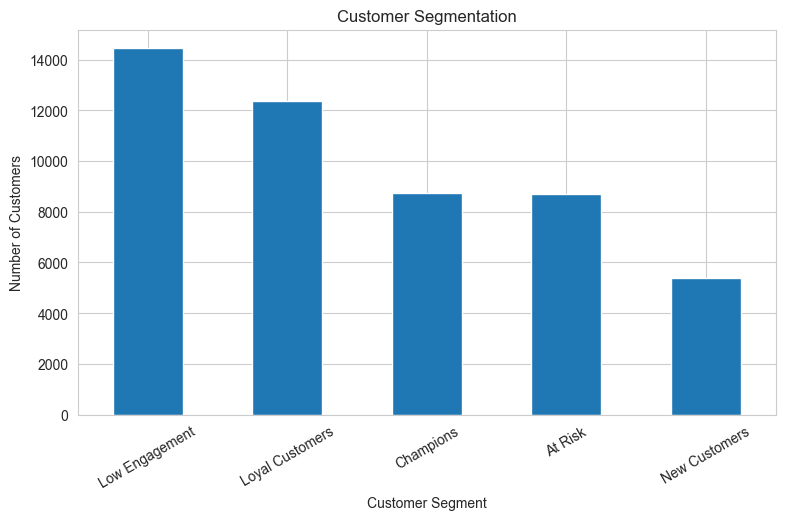

In [37]:
plt.figure(figsize=(9,5))

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [38]:
print("Churn distribution:")
print(df["Churn"].value_counts())

Churn distribution:
Churn
0    200126
1     49874
Name: count, dtype: int64


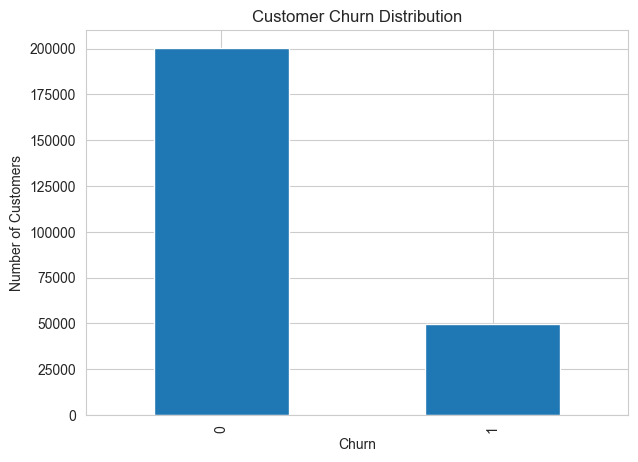

In [39]:
plt.figure(figsize=(7,5))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [41]:
purchase_frequency = (
    df.groupby("Customer ID")
    .size()
)

repeat_customers = (
    purchase_frequency > 1
).sum()

total_customers = len(
    purchase_frequency
)

repeat_rate = (
    repeat_customers /
    total_customers
) * 100

print(
    "Repeat Customer Rate:",
    round(repeat_rate, 2),
    "%"
)

Repeat Customer Rate: 96.61 %


In [42]:
top_customers = (
    rfm.sort_values(
        "Monetary",
        ascending=False
    )
    .head(10)
)

display(top_customers)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
Customer ID,,,,,,,
36437,21,17,55339,5,5,5,Champions
39817,195,17,51718,3,5,5,Loyal Customers
26977,15,14,48497,5,5,5,Champions
5844,32,12,46541,5,5,5,Champions
3576,243,14,46518,3,5,5,Loyal Customers
13802,17,13,46464,5,5,5,Champions
809,21,15,45738,5,5,5,Champions
47087,105,17,45700,4,5,5,Champions
14400,84,15,45334,4,5,5,Champions


In [45]:
print("=" * 60)
print("CUSTOMER BEHAVIOR ANALYSIS SUMMARY")
print("=" * 60)

print("Total Customers:",
      df["Customer ID"].nunique())

print("Total Transactions:",
      len(df))

print("Total Revenue:",
      round(df["Total Purchase Amount"].sum(), 2))

print("Average Purchase Amount:",
      round(df["Total Purchase Amount"].mean(), 2))

print("Repeat Customer Rate:",
      round(repeat_rate, 2), "%")



CUSTOMER BEHAVIOR ANALYSIS SUMMARY
Total Customers: 49673
Total Transactions: 250000
Total Revenue: 681342683
Average Purchase Amount: 2725.37
Repeat Customer Rate: 96.61 %
